# Request a SO-ARM101 (LeRobot)

Provision a Chameleon Edge device for SO-ARM101 robot arm teleoperation and
data collection using HuggingFace LeRobot.

## Prerequisites
- Active Chameleon Cloud allocation (project `CHI-261589`)
- A SO-ARM101 device registered on CHI@Edge
- Container image with LeRobot + teleoperation stack pushed to Docker Hub
- python-chi 1.0+ (`pip install python-chi`)

In [64]:
# Step 1: Install dependencies
# Install dependencies into the current kernel environment using uv
import subprocess, sys

subprocess.run(
    [
        "uv", "pip", "install", f"--python={sys.executable}",
        "python-chi",
        "python-blazarclient",
        "python-zunclient @ git+https://github.com/ChameleonCloud/python-zunclient.git",
    ],
    check=True,
)
print("Dependencies ready.")


Using Python 3.12.13 environment at: /home/cc/.venv


Dependencies ready.


Resolved 112 packages in 870ms
Checked 112 packages in 4ms


In [65]:
# Step 2: Load CHI@Edge credentials
# Load CHI@Edge application credentials into the kernel environment
import subprocess, os, pathlib, chi

RC_FILE = pathlib.Path.cwd() / "ansible/app-cred-chi-edge-openrc.sh"
if not RC_FILE.exists():
    raise RuntimeError("RC file not found: " + str(RC_FILE))

result = subprocess.run(
    ["bash", "-c", f"source {RC_FILE} && env"],
    capture_output=True, text=True, check=True,
)
for line in result.stdout.splitlines():
    if line.startswith("OS_"):
        key, _, val = line.partition("=")
        os.environ[key] = val

# Required by keystoneauth v3applicationcredential when project_name is present in env
os.environ.setdefault("OS_PROJECT_DOMAIN_NAME", "chameleon")

# Reset chi session AFTER env vars are loaded so it picks up the correct auth plugin
chi.reset()

print("CHI@Edge credentials loaded:")
for k in sorted(k for k in os.environ if k.startswith("OS_")):
    masked = "***" if "SECRET" in k or "PASSWORD" in k else os.environ[k]
    print(f"  {k} = {masked}")


CHI@Edge credentials loaded:
  OS_APPLICATION_CREDENTIAL_ID = 76db5a9b46744260856ea7fdc5247075
  OS_APPLICATION_CREDENTIAL_SECRET = ***
  OS_AUTH_TYPE = v3applicationcredential
  OS_AUTH_URL = https://chi.edge.chameleoncloud.org:5000/v3
  OS_IDENTITY_API_VERSION = 3
  OS_INTERFACE = public
  OS_PROJECT_DOMAIN_NAME = chameleon
  OS_REGION_NAME = CHI@Edge


In [66]:
# Step 3: Configure CHI@Edge site and load constants
import chi, base64
from datetime import timedelta
from chi.lease import Lease
from chi.container import Container

chi.use_site("CHI@Edge")

# ── Notebook-wide constants ──
LEASE_NAME     = "lerobot-soarm101-lease"
CONTAINER_NAME = "lerobot-soarm101-container"
DEVICE_NAME    = "soarm101-1"
HF_USER        = "ricklon"

# ── Guard helper ──
def require(**kwargs):
    """Raise a clear error if a named variable is not set in notebook state."""
    import sys
    g = sys._getframe(1).f_globals
    missing = [name for name, hint in kwargs.items() if name not in g]
    if missing:
        hints = [kwargs[n] for n in missing]
        msg = "\n".join(f"  '{n}' — {h}" for n, h in zip(missing, hints))
        raise RuntimeError(f"Missing required state. Run these cells first:\n{msg}")

# ── exec_python helper ──
def exec_python(container, script: str) -> tuple[str, int]:
    """Run a Python script in the container without shell quoting issues.

    Encodes the script as base64 and runs it via:
        python3 -c "import base64; exec(base64.b64decode('...').decode())"

    Single quotes around the b64 payload prevent the shell from splitting on
    the encoded data, which may contain characters that confuse double-quote
    parsing.

    Returns (output, exit_code).
    """
    b64 = base64.b64encode(script.encode()).decode()
    cmd = f"python3 -c \"import base64; exec(base64.b64decode('{b64}').decode())\""
    return container.execute(cmd)

print("Setup complete. Constants, require(), and exec_python() loaded.")


Now using CHI@Edge:
URL: https://chi.edge.chameleoncloud.org
Location: University of Chicago, Chicago, Illinois, USA
Support contact: help@chameleoncloud.org
Setup complete. Constants, require(), and exec_python() loaded.


## Reconnect to existing session

If a lease and container are already running (e.g. you reopened this notebook),
run this cell to restore `my_lease` and `my_container` without recreating anything.
Skip to **Verify the environment** once the floating IP is printed.

In [67]:
# Step 4a: Reconnect to existing session (skip to 4b if starting fresh)
from chi import lease as lease_api, clients, network as chi_network

require(LEASE_NAME="run the setup-chi cell first")

# ── Reconnect to lease ──
my_lease = lease_api.get_lease(LEASE_NAME)
if my_lease is None or my_lease.status not in ("ACTIVE", "PENDING"):
    raise RuntimeError(f"No active lease '{LEASE_NAME}' — run the Lease cell below to create one.")
print(f"Lease '{my_lease.name}' [{my_lease.status}] — ends {my_lease.end_date}")

# ── Reconnect to container ──
zun = clients.zun()
matches = [c for c in zun.containers.list() if c.name == CONTAINER_NAME]
if not matches:
    raise RuntimeError(f"No container '{CONTAINER_NAME}' found — run the Launch cell below.")
my_container = Container.from_zun_container(matches[0])
print(f"Container '{my_container.name}' [{my_container.status}]")

# ── Find existing floating IP ──
c = zun.containers.get(my_container.name)
port_id = None
for net_id, addrs in c.addresses.items():
    port_id = next((a["port"] for a in addrs if a.get("port")), None)
    if port_id:
        break

fips = chi_network.neutron().list_floatingips(port_id=port_id)["floatingips"] if port_id else []
if fips:
    fip = fips[0]["floating_ip_address"]
    print(f"\nFloating IP : {fip}")
    print(f"SSH         : ssh root@{fip}")
else:
    print("No floating IP yet — run Step 8.")


RuntimeError: No active lease 'lerobot-soarm101-lease' — run the Lease cell below to create one.

## Lease the device

Request (or reuse) a lease for the SO-ARM101 edge device. If an active lease
named `LEASE_NAME` already exists it will be reused — safe to re-run.

In [68]:
# Step 4b: Lease the device (skip if you ran 4a successfully)
from chi import lease as lease_api

require(LEASE_NAME="run the setup-chi cell first")

# Check for existing active lease before creating
my_lease = None
try:
    existing = lease_api.get_lease(LEASE_NAME)
    if existing and existing.status in ("ACTIVE", "PENDING"):
        my_lease = existing
        print(f"Reusing lease '{my_lease.name}' [{my_lease.status}]")
        print(f"  ID:   {my_lease.id}")
        print(f"  Ends: {my_lease.end_date}")
except Exception:
    pass

if my_lease is None:
    print(f"No active lease named '{LEASE_NAME}'. Creating...")
    my_lease = Lease(name=LEASE_NAME, duration=timedelta(days=7))
    my_lease.add_device_reservation(device_name=DEVICE_NAME, amount=1)
    my_lease.submit(wait_for_active=True, idempotent=True)
    print(f"Lease '{my_lease.name}' is {my_lease.status} (id: {my_lease.id})")
    print(f"Ends: {my_lease.end_date}")


No active lease named 'lerobot-soarm101-lease'. Creating...


error: internal server error


ResourceError: Unable to make lease

## Launch the container

Creates the container with serial port and camera access. Safe to re-run.

### Device profile status

| Profile | Exposes | Status |
|---------|---------|--------|
| `ttyacm0` | `/dev/ttyACM0` — leader arm | ✅ Working |
| `ttyacm1` | `/dev/ttyACM1` — follower arm | ✅ Working |
| `video0` | C920 capture node | ✅ Working |
| `video1` | C920 metadata/control node | ✅ Working |
| `video2` | Gripper camera capture node | ✅ Working |
| `video3` | Gripper camera metadata/control node | ✅ Working |

> **Important:** The local `coachable-preview` container and the CHI@Edge container
> share the same physical cameras. Stop the preview before using cameras via CHI@Edge:
> `ssh -p 22222 root@192.168.4.191 "balena stop coachable-preview"`

In [ ]:
# Step 5: Launch the container on the Pi
import time, subprocess, yaml, pathlib
from chi import clients

require(
    my_lease="run the 'Lease the device' or 'Reconnect' cell first",
    LEASE_NAME="run the setup-chi cell first",
)

# ── Check for existing usable container ──
zun = clients.zun()
existing = [c for c in zun.containers.list() if c.name == CONTAINER_NAME]
if existing and existing[0].status.lower() == "running":
    my_container = Container.from_zun_container(existing[0])
    print(f"Reusing existing container '{my_container.name}' [{existing[0].status}]")
    print(f"ID: {existing[0].uuid}")
else:
    if existing:
        stale = existing[0]
        print(f"Found container in [{stale.status}] — deleting and recreating...")
        Container.from_zun_container(stale).delete()
        for _ in range(12):
            time.sleep(5)
            if not any(c.name == CONTAINER_NAME for c in zun.containers.list()):
                print("  Deleted.")
                break
        else:
            raise RuntimeError("Timed out waiting for stale container to delete.")

    # ── Load HF token from Ansible vault ──
    ANSIBLE_DIR = pathlib.Path.cwd() / "ansible"
    VAULT_FILE = ANSIBLE_DIR / "group_vars/all/vault.yml"
    VAULT_PASS_FILE = ANSIBLE_DIR / ".vault_pass"
    if not VAULT_PASS_FILE.exists():
        raise RuntimeError("ansible/.vault_pass not found.")

    result = subprocess.run(
        ["uv", "run", "--with", "ansible", "ansible-vault", "view", str(VAULT_FILE),
         "--vault-password-file", str(VAULT_PASS_FILE)],
        capture_output=True, text=True, check=True,
    )
    vault_vars = yaml.safe_load(result.stdout)
    hf_token = vault_vars["vault_hf_token"]
    print("HF token loaded from vault OK")

    # ── Load control-node SSH public key for container access ──
    ssh_pub_path = pathlib.Path.home() / ".ssh" / "id_ed25519.pub"
    ssh_pubkey = ssh_pub_path.read_text().strip() if ssh_pub_path.exists() else ""
    if ssh_pubkey:
        print(f"SSH public key loaded: {ssh_pub_path}")
    else:
        print("WARNING: no ~/.ssh/id_ed25519.pub found — SSH into container won't work")

    reservation_id = my_lease.device_reservations[0]["id"]
    my_container = Container(
        name=CONTAINER_NAME,
        # chi-edge channel: app image + openssh-server + entrypoint.sh
        # Same Gradio, coachable, LeRobot as balena/local — apples-to-apples
        image_ref="rianders/lerobot-soarm101:chi-edge",
        reservation_id=reservation_id,
        command=["sleep", "infinity"],
        environment={
            "HF_TOKEN": hf_token,
            "HF_USER": HF_USER,
            "LEADER_PORT": "/dev/ttyACM0",
            "FOLLOWER_PORT": "/dev/ttyACM1",
            "CAMERA_INDEX": "0",
            "SSH_PUBKEY": ssh_pubkey,
        },
        device_profiles=["ttyacm0", "ttyacm1", "video0", "video1", "video2", "video3"],
    )
    my_container.submit(wait_for_active=True, idempotent=True)
    print(f"Container '{my_container.name}' is {my_container.status}")
    print(f"ID: {my_container.zun_container.uuid}")


In [7]:
# Step 6: Check container logs
require(my_container="run the 'Launch the container' or 'Reconnect' cell first")
print(my_container.logs())

In [8]:
# Step 7: Check container status
require(my_container="run the 'Launch the container' or 'Reconnect' cell first")
print(f"Container '{my_container.name}' is {my_container.status}")

Container 'lerobot-soarm101-container' is Running


## Assign a floating IP

In [ ]:
# Step 8: Assign a floating IP for SSH access
require(my_container="run the 'Launch the container' or 'Reconnect' cell first")

from chi import clients, network as chi_network

# Check if container already has a floating IP bound to its port
zun = clients.zun()
c = zun.containers.get(my_container.name)
port_id = None
for net_id, addrs in c.addresses.items():
    port_id = next((a["port"] for a in addrs if a.get("port")), None)
    if port_id:
        break

existing_fips = chi_network.neutron().list_floatingips(port_id=port_id)["floatingips"] if port_id else []

if existing_fips:
    fip = existing_fips[0]["floating_ip_address"]
    print(f"Reusing existing floating IP: {fip}")
else:
    fip = my_container.associate_floating_ip()
    print(f"Assigned new floating IP: {fip}")

print()
print(f"SSH into the container (from a JupyterLab terminal):")
print(f"  ssh root@{fip}")
print()
print(f"Investigate cameras:")
print(f"  v4l2-ctl --list-devices")
print(f"  fuser /dev/video0             # what holds the device")
print(f"  python3 -c \"import cv2; cap=cv2.VideoCapture(0); print(cap.isOpened(), cap.read()[0])\"")


## Verify the environment

Check that the camera, LeRobot, and USB devices are accessible.

In [10]:
# Step 9: Verify container filesystem
require(my_container="run the 'Launch the container' or 'Reconnect' cell first")
output, exit_code = my_container.execute("ls -l")
print(output)


total 28
drwxr-xr-x  2 root root 4096 Apr  9 01:56 calibration
drwxr-xr-x  2 root root 4096 Apr  9 01:56 checkpoints
drwxr-xr-x  1 root root 4096 Apr  9 01:54 coachable-robots
drwxr-xr-x  2 root root 4096 Apr  9 01:56 config
drwxr-xr-x  2 root root 4096 Apr  9 01:56 data
drwxr-xr-x 11 root root 4096 Apr  9 01:52 lerobot
drwxr-xr-x  1 root root 4096 Apr  9 01:29 scripts



In [11]:
# Step 10: Verify arm serial ports are accessible
require(my_container="run the 'Launch the container' or 'Reconnect' cell first")
output, _ = my_container.execute("bash -c 'ls -l /dev/ttyACM* 2>/dev/null || echo No ttyACM devices found'")
print(output)


crw-rw---- 1 root dialout 166, 0 Apr  9 12:51 /dev/ttyACM0
crw-rw---- 1 root dialout 166, 1 Apr  9 12:51 /dev/ttyACM1



In [23]:
# Step 11: Verify cameras are accessible
require(my_container="run the 'Launch the container' or 'Reconnect' cell first")
output, _ = my_container.execute("bash -c 'ls -l /dev/video* 2>/dev/null || echo No video devices found'")
print(output)
output, _ = my_container.execute("bash -c 'v4l2-ctl --device=/dev/video0 --info 2>/dev/null | head -10 || echo v4l2-ctl not available'")
print(output)


crw-rw---- 1 root video 81,  9 Apr  9 12:51 /dev/video0
crw-rw---- 1 root video 81, 11 Apr  9 12:51 /dev/video1
crw-rw---- 1 root video 81, 19 Apr  9 12:51 /dev/video2
crw-rw---- 1 root video 81, 20 Apr  9 12:51 /dev/video3

Driver Info:
	Driver name      : uvcvideo
	Card type        : HD Pro Webcam C920
	Bus info         : usb-xhci-hcd.1-1
	Driver version   : 6.12.61
	Capabilities     : 0x84a00001
		Video Capture
		Metadata Capture
		Streaming
		Extended Pix Format



exit_code='0'  output=Captured 1280x720 frame OK
Saved to /tmp/test_frame.jpg (266 KB)


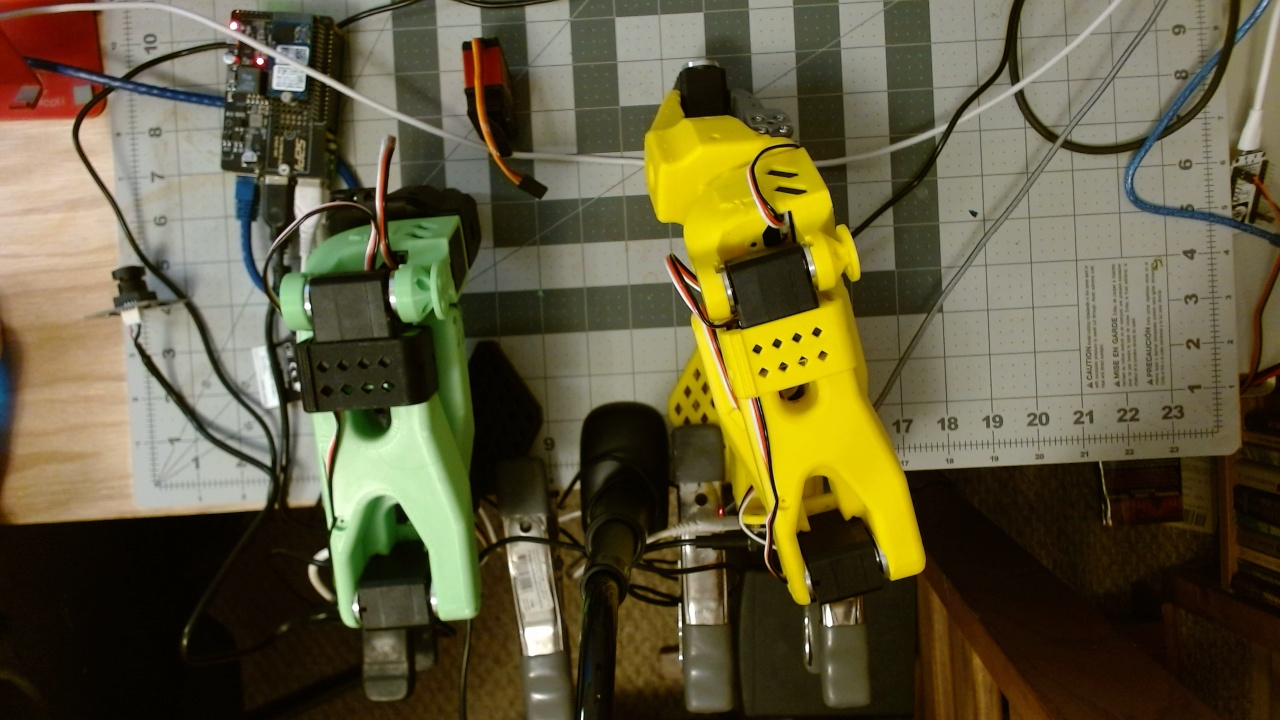

In [51]:
# Step 12: Capture a test frame from the camera
require(my_container="run the 'Launch the container' or 'Reconnect' cell first")
import base64 as _b64
from IPython.display import Image, display

# Capture frame and write JPEG inside the container
output, exit_code = exec_python(my_container, '''
import cv2, sys
cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)
ret, frame = cap.read()
cap.release()
if not ret:
    print("ERROR: could not read frame", file=sys.stderr)
    sys.exit(1)
cv2.imwrite("/tmp/test_frame.jpg", frame)
h, w = frame.shape[:2]
print(f"Captured {w}x{h} frame OK")
''')
print(f"exit_code={exit_code!r}  output={output.strip()}")

# exit_code may be int or str depending on the zunclient version; check output content
if "Captured" in output:
    # Transfer via base64 — avoids Container.download() path issues
    b64_out, _ = my_container.execute("bash -c 'base64 -w 0 /tmp/test_frame.jpg'")
    img_bytes = _b64.b64decode(b64_out.strip())
    local_path = "/tmp/test_frame.jpg"
    with open(local_path, "wb") as fh:
        fh.write(img_bytes)
    print(f"Saved to {local_path} ({len(img_bytes)//1024} KB)")
    display(Image(filename=local_path))
else:
    print("Camera capture failed — check /dev/video0 is exposed and the preview container is stopped.")
    print(f"Container output: {output.strip()}")


In [39]:
# Step 13: Verify LeRobot is installed
require(my_container="run the 'Launch the container' or 'Reconnect' cell first")

v_out, _ = my_container.execute("python3 --version")
print(v_out.strip())

output, _ = exec_python(my_container, "import lerobot; print('LeRobot:', lerobot.__version__)")
print(output.strip())


Python 3.12.13
LeRobot: 0.5.0


## Live System Monitor

A Gradio dashboard that polls the container for device status and live camera frames.
Useful for confirming the arm and cameras are ready before starting data collection.
Re-run this cell any time to relaunch the dashboard.

In [52]:
# Step 14: Live system monitor — three-column layout: Status | Top cam | Gripper cam
import ipywidgets as widgets
import base64 as _b64
from IPython.display import display, Image, clear_output
import datetime

require(my_container="run the 'Launch the container' or 'Reconnect' cell first")

# Camera profiles
CAMERA_PROFILES = {
    0: dict(name="Top (C920)",               dev="video0", w=1280, h=720,  fps=30, fourcc="YUYV", warmup=10),
    2: dict(name="Gripper (OV2710 fisheye)", dev="video2", w=1920, h=1080, fps=30, fourcc="MJPG", warmup=20),
}

# ── Helpers ────────────────────────────────────────────────────────────────────

def get_system_status():
    now = datetime.datetime.now().strftime("%H:%M:%S")
    rows = [f"Updated   : {now}",
            f"Container : {my_container.name}  [{my_container.status}]"]

    out, _ = my_container.execute("bash -c 'ls /dev/ttyACM* 2>/dev/null || echo NONE'")
    rows.append(f"Serial    : {'  '.join(out.strip().split()) or 'NONE'}")

    out, _ = my_container.execute("bash -c 'ls /dev/video* 2>/dev/null || echo NONE'")
    rows.append(f"Cameras   : {'  '.join(out.strip().split()) or 'NONE'}")

    for idx, prof in CAMERA_PROFILES.items():
        dev = prof["dev"]
        out, _ = my_container.execute(
            f"bash -c 'v4l2-ctl --device=/dev/{dev} --info 2>/dev/null"
            f" | grep \"Card type\" | sed \"s/.*: //\" || echo unavailable'"
        )
        rows.append(f"  cam{idx}: {out.strip()}")

    out, _ = exec_python(my_container, "import lerobot; print(lerobot.__version__)")
    rows.append(f"LeRobot   : {out.strip() if out.strip() and 'Error' not in out else 'not found'}")

    return "\n".join(rows)


def capture_frame(camera_index):
    prof = CAMERA_PROFILES[camera_index]
    w, h, fps, fourcc_str, warmup = prof["w"], prof["h"], prof["fps"], prof["fourcc"], prof["warmup"]

    pre = ""
    if camera_index == 2:
        pre = ("v4l2-ctl --device=/dev/video2 "
               "--set-ctrl=exposure_dynamic_framerate=0 "
               "--set-ctrl=backlight_compensation=2 2>/dev/null || true")

    script = f"""
import cv2, sys, subprocess
{f'subprocess.run("{pre}", shell=True)' if pre else ''}
cap = cv2.VideoCapture({camera_index})
cap.set(cv2.CAP_PROP_FOURCC, cv2.VideoWriter_fourcc(*'{fourcc_str}'))
cap.set(cv2.CAP_PROP_FRAME_WIDTH,  {w})
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, {h})
cap.set(cv2.CAP_PROP_FPS, {fps})
for _ in range({warmup}):
    cap.grab()
ret, frame = cap.read()
cap.release()
if not ret or frame is None:
    print("ERROR", file=sys.stderr); sys.exit(1)
cv2.imwrite("/tmp/preview_{camera_index}.jpg", frame)
fh, fw = frame.shape[:2]
print(f"OK {{fw}}x{{fh}} brightness={{frame.mean():.1f}}")
"""
    output, _ = exec_python(my_container, script)
    if "OK" not in output:
        return None, f"failed: {output.strip()}"

    b64_out, _ = my_container.execute(f"bash -c 'base64 -w 0 /tmp/preview_{camera_index}.jpg'")
    img_bytes = _b64.b64decode(b64_out.strip())
    local_path = f"/tmp/chi_preview_{camera_index}.jpg"
    with open(local_path, "wb") as fh:
        fh.write(img_bytes)
    return local_path, output.strip()


# ── Widgets ────────────────────────────────────────────────────────────────────

COL_W = "320px"

status_area = widgets.Textarea(
    value="Click Refresh to poll…",
    layout=widgets.Layout(width=COL_W, height="260px"),
)
refresh_btn = widgets.Button(description="Refresh Status", button_style="primary",
                             icon="refresh", layout=widgets.Layout(width=COL_W))

cam0_out   = widgets.Output(layout=widgets.Layout(width=COL_W, height="220px"))
cam0_label = widgets.Label(value="Top (C920)")

cam2_out   = widgets.Output(layout=widgets.Layout(width=COL_W, height="220px"))
cam2_label = widgets.Label(value="Gripper (OV2710)")

capture_btn    = widgets.Button(description="Capture Both Cameras", button_style="info",
                                icon="camera", layout=widgets.Layout(width="320px"))
capture_status = widgets.Label(value="")


def on_refresh(_):
    refresh_btn.disabled = True
    refresh_btn.description = "Polling…"
    try:
        status_area.value = get_system_status()
    finally:
        refresh_btn.disabled = False
        refresh_btn.description = "Refresh Status"


def on_capture(_):
    capture_btn.disabled = True
    capture_btn.description = "Capturing…"
    capture_status.value = ""
    try:
        results = {}
        for idx, out_widget, label_widget in [
            (0, cam0_out, cam0_label),
            (2, cam2_out, cam2_label),
        ]:
            path, info = capture_frame(idx)
            prof = CAMERA_PROFILES[idx]
            with out_widget:
                clear_output(wait=True)
                if path:
                    display(Image(filename=path, width=int(COL_W.replace("px", "")) - 10))
                else:
                    print(info)
            label_widget.value = f"{prof['name']}: {info}"
            results[idx] = info
        capture_status.value = f"cam0: {results[0]}  |  cam2: {results[2]}"
    finally:
        capture_btn.disabled = False
        capture_btn.description = "Capture Both Cameras"


refresh_btn.on_click(on_refresh)
capture_btn.on_click(on_capture)

display(widgets.VBox([
    widgets.HTML(f"<h3>SO-ARM101 Monitor — {my_container.name}</h3>"),
    widgets.HBox([
        widgets.VBox([
            widgets.HTML("<b>System Status</b>"),
            status_area,
            refresh_btn,
        ], layout=widgets.Layout(margin="0 12px 0 0")),
        widgets.VBox([
            widgets.HTML("<b>Top Camera (C920e)</b>"),
            cam0_out,
            cam0_label,
        ], layout=widgets.Layout(margin="0 12px 0 0")),
        widgets.VBox([
            widgets.HTML("<b>Gripper Camera (OV2710 fisheye)</b>"),
            cam2_out,
            cam2_label,
        ]),
    ]),
    widgets.HBox([capture_btn, capture_status]),
]))


In [53]:
# Step 14b: Dual-camera live preview — position Top (C920e) and Gripper (OV2710)
# Uses widgets.Image for thread-safe display. Both cameras captured per frame.

import threading, base64 as _b64, datetime
import ipywidgets as widgets
from IPython.display import display

require(my_container="run the 'Launch the container' or 'Reconnect' cell first")

# Capture both cameras in one exec_python call for efficiency
_DUAL_CAPTURE = """
import cv2, sys, subprocess
subprocess.run(
    'v4l2-ctl --device=/dev/video2 '
    '--set-ctrl=exposure_dynamic_framerate=0 '
    '--set-ctrl=backlight_compensation=2 2>/dev/null',
    shell=True
)
CAMS = [
    (0, 'YUYV', 1280, 720,  480, 270, '/tmp/live_0.jpg'),
    (2, 'MJPG', 1920, 1080, 640, 360, '/tmp/live_2.jpg'),
]
results = {}
for idx, fourcc_str, w, h, sw, sh, path in CAMS:
    cap = cv2.VideoCapture(idx)
    cap.set(cv2.CAP_PROP_FOURCC, cv2.VideoWriter_fourcc(*fourcc_str))
    cap.set(cv2.CAP_PROP_FRAME_WIDTH,  w)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, h)
    cap.set(cv2.CAP_PROP_FPS, 30)
    for _ in range(5): cap.grab()
    ret, frame = cap.read()
    cap.release()
    if ret and frame is not None:
        small = cv2.resize(frame, (sw, sh))
        cv2.imwrite(path, small, [cv2.IMWRITE_JPEG_QUALITY, 75])
        results[idx] = f'OK brightness={frame.mean():.1f}'
    else:
        results[idx] = 'ERROR'
print(f"cam0={results.get(0,'?')} cam2={results.get(2,'?')}")
"""

# ── Widgets ───────────────────────────────────────────────────────────────────

# widgets.Image updates its .value in-place — thread-safe, no Output flicker
_PLACEHOLDER = _b64.b64decode(
    b'/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBwcJCQgKDBQNDAsLDBkSEw8U'
    b'HRofHh0aHBwgJC4nICIsIxwcKDcpLDAxNDQ0Hyc5PTgyPC4zNDL/2wBDAQkJCQwLDBgN'
    b'DRgyIRwhMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIy'
    b'MjL/wAARCAABAAEDASIAAhEBAxEB/8QAFAABAAAAAAAAAAAAAAAAAAAACf/EABQQAQAAAAAA'
    b'AAAAAAAAAAAAAP/EABQBAQAAAAAAAAAAAAAAAAAAAAD/xAAUEQEAAAAAAAAAAAAAAAAAAAAA'
    b'/9oADAMBAAIRAxEAPwCwABmX/9k='
)

cam0_img   = widgets.Image(value=_PLACEHOLDER, format='jpeg', width=480, height=270)
cam0_label = widgets.Label(value='Top (C920e) — not started')
cam2_img   = widgets.Image(value=_PLACEHOLDER, format='jpeg', width=640, height=360)
cam2_label = widgets.Label(value='Gripper (OV2710) — not started')
fps_label  = widgets.Label(value='')

start_btn = widgets.Button(description='Start Stream', button_style='success', icon='play',
                            layout=widgets.Layout(width='160px'))
stop_btn  = widgets.Button(description='Stop', button_style='danger', icon='stop',
                            layout=widgets.Layout(width='120px'))
stop_btn.disabled = True

_stop_event = threading.Event()


def _stream_loop():
    frame_count = 0
    while not _stop_event.is_set():
        t0 = datetime.datetime.now()

        output, _ = exec_python(my_container, _DUAL_CAPTURE)

        # Transfer cam0
        if 'cam0=OK' in output:
            b64_raw, _ = my_container.execute("bash -c 'base64 -w 0 /tmp/live_0.jpg'")
            try:
                cam0_img.value = _b64.b64decode(b64_raw.strip())
                cam0_label.value = 'Top (C920e) 1280x720 -> 480x270'
            except Exception as e:
                cam0_label.value = f'decode error: {e}'
        else:
            cam0_label.value = f'cam0 error: {output.strip()}'

        # Transfer cam2
        if 'cam2=OK' in output:
            b64_raw, _ = my_container.execute("bash -c 'base64 -w 0 /tmp/live_2.jpg'")
            try:
                cam2_img.value = _b64.b64decode(b64_raw.strip())
                cam2_label.value = 'Gripper (OV2710) 1920x1080 -> 640x360'
            except Exception as e:
                cam2_label.value = f'decode error: {e}'
        else:
            cam2_label.value = f'cam2 error: {output.strip()}'

        elapsed = (datetime.datetime.now() - t0).total_seconds()
        frame_count += 1
        fps_label.value = (
            f'Frame {frame_count} | {elapsed*1000:.0f} ms/frame (~{1/elapsed:.1f} fps) | '
            + output.strip()
        )

    fps_label.value = f'Stopped after {frame_count} frames'


def on_start(_):
    _stop_event.clear()
    start_btn.disabled = True
    stop_btn.disabled  = False
    fps_label.value    = 'Starting...'
    threading.Thread(target=_stream_loop, daemon=True).start()


def on_stop(_):
    _stop_event.set()
    start_btn.disabled = False
    stop_btn.disabled  = True


start_btn.on_click(on_start)
stop_btn.on_click(on_stop)

display(widgets.VBox([
    widgets.HTML(
        '<h3>Dual Camera Live Preview</h3>'
        '<p style="color:#666;font-size:0.85em">'
        '~2-4 fps via SSH.</p>'
        '<p style="background:#fff3cd;border-left:4px solid #f0ad4e;padding:6px 10px;font-size:0.85em">'
        '<b>Stop the stream before collecting data.</b> '
        'This stream holds /dev/video0 and /dev/video2 open. '
        'lerobot-record will fail to open the cameras if the stream is running.</p>'
    ),
    widgets.HBox([start_btn, stop_btn]),
    widgets.HBox([
        widgets.VBox([
            widgets.HTML('<b>Top Camera (C920e) — /dev/video0</b>'),
            cam0_img,
            cam0_label,
        ], layout=widgets.Layout(margin='0 20px 0 0')),
        widgets.VBox([
            widgets.HTML('<b>Gripper Camera (OV2710 fisheye) — /dev/video2</b>'),
            cam2_img,
            cam2_label,
        ]),
    ]),
    fps_label,
]))


## Robot Arm Verification

Before collecting data, confirm the arms are calibrated and responding to commands.
Two options:
- **Calibration check** — verify calibration files exist; run calibration if missing
- **Arm control test** — teleoperate manually, or replay a hello-world reference motion to verify the follower responds


In [ ]:
# Step 14c: Sync source + Launch Gradio preview on the Pi container
#
# Source sync: git pull inside container (editable install — no rebuild needed).
# Prerequisite: commit and push changes from the Jupyter terminal first:
#   cd ~/coachable-robots && git add -A && git commit -m "update preview" && git push
#
# IMPORTANT: Stop the Step 14b stream first — it holds video0/video2 open.

require(my_container="run the \'Launch the container\' or \'Reconnect\' cell first")

# ── Pull latest source inside container ──────────────────────────────────────
pull_out, _ = my_container.execute(
    "bash -c 'cd /app/coachable-robots && git pull 2>&1'"
)
print("git pull:", pull_out.strip())

# ── Kill any prior preview ───────────────────────────────────────────────────
kill_script = """
import subprocess, os, signal, re, socket, time
try:
    pid = int(open('/tmp/preview.pid').read().strip())
    os.kill(pid, signal.SIGKILL)
    print(f'Killed PID {pid}')
except Exception:
    pass
for name in ['coachable', 'uvicorn']:
    subprocess.run(['pkill', '-9', '-f', name], capture_output=True)
r = subprocess.run(['ss', '-tlnp'], capture_output=True, text=True)
for line in r.stdout.splitlines():
    if '786' in line:
        for m in re.finditer(r'pid=(\\d+)', line):
            try: os.kill(int(m.group(1)), signal.SIGKILL)
            except Exception: pass
time.sleep(2)
free = [p for p in range(7860, 7871) if (lambda s: (s.setsockopt(32, 2, 1), s.bind((\'\', p)), s.close(), True) or True)(socket.socket())]
print(f'Free ports: {free}')
"""
out, _ = exec_python(my_container, kill_script)
print(out.strip())

# ── Patch fleet.yaml + launch ────────────────────────────────────────────────
my_container.execute("sed -i \'s/gripper: 1/gripper: 2/g\' /app/config/fleet.yaml")
my_container.execute(
    "bash -c 'rm -f /tmp/preview.pid /tmp/preview.port; "
    "setsid nohup coachable preview --robot alpha --calibration-dir /app/calibration "
    "> /tmp/preview.log 2>&1 </dev/null &'"
)

# ── Wait for port file ───────────────────────────────────────────────────────
import time
port_str = ""
for _ in range(15):
    time.sleep(1)
    port_out, _ = my_container.execute(
        "bash -c \'cat /tmp/preview.port 2>/dev/null || echo waiting\'"
    )
    port_str = port_out.strip()
    if port_str.isdigit():
        break

if port_str.isdigit():
    url = f"http://{fip}:{port_str}"
    print(f"\nGradio preview running: {url}")
    print("Open that URL in a new browser tab.")
    print("Panels: Live Cameras | System Status | Arm Control | Calibration")
else:
    log_out, _ = my_container.execute(
        "bash -c \'tail -30 /tmp/preview.log 2>/dev/null || echo no log\'"
    )
    print("Preview did not start. Log:")
    print(log_out)


In [ ]:
# Step 14d: Arm control test — verify follower and leader serial ports respond
# Teleoperation and calibration commands are shown in the Gradio preview (Step 14c).

require(my_container="run the 'Launch the container' or 'Reconnect' cell first")

# Read ports from fleet config inside the container (avoids hardcoding)
fleet_out, _ = my_container.execute(
    "python3 -c \"import yaml; c=yaml.safe_load(open('/app/config/fleet.yaml')); "
    "r=c['fleet']['robots'][0]; print(r['follower_port'], r['leader_port'])\""
)
ports = fleet_out.strip().split()
follower_port = ports[0] if len(ports) >= 1 else "/dev/ttyACM1"
leader_port   = ports[1] if len(ports) >= 2 else "/dev/ttyACM0"
print(f"Follower: {follower_port}  Leader: {leader_port}")

hello_world = f"""
import sys, os, serial

acm = sorted(f for f in os.listdir('/dev') if f.startswith('ttyACM'))
if not acm:
    print("ERROR: No /dev/ttyACM* devices — check USB connections")
    sys.exit(1)
print(f"Serial ports present: {{acm}}")

errors = []
for port in ['{follower_port}', '{leader_port}']:
    try:
        ser = serial.Serial(port, baudrate=1000000, timeout=0.5)
        ser.close()
        print(f"OK  {{port}}")
    except Exception as e:
        errors.append(port)
        print(f"FAIL {{port}}: {{e}}")

if errors:
    print("\nArm serial check failed — check USB connections.")
    sys.exit(1)

print("\nBoth arm serial ports accessible. Hello world OK.")
print("For teleoperation or calibration commands, see the Gradio preview (Step 14c).")
"""

out, _ = exec_python(my_container, hello_world)
print(out.strip())

if "Hello world OK" in out:
    print()
    print("Arms accessible. Ready to collect data (Step 15).")
elif "ERROR" in out or "FAIL" in out:
    print()
    print("Check connections — run Step 10 to verify serial ports.")


## Teleoperation & Data Collection

Both serial ports (`ttyACM0` leader, `ttyACM1` follower) are now exposed via
`device_profiles=["ttyacm0", "ttyacm1", "pi_libcamera"]`.

### Supported training policies
- **ACT** — recommended for MI100 (no Flash Attention needed)
- **Diffusion** — heavier compute, solid results
- **SmolVLA** — lightweight VLA for constrained hardware

In [50]:
# Step 15: Record demonstration episodes
require(my_container="run the 'Launch the container' or 'Reconnect' cell first")
record_cmd = 'bash /app/scripts/collect_demos.sh soarm101_demos 20 "Pick up the object and place it in the target location"'
print("Starting data collection ...")
output, _ = my_container.execute(f"bash -c '{record_cmd}'")
print(output)


Starting data collection ...
=== SO-ARM101 Demo Collection ===
Dataset:  ricklon/soarm101_demos
Episodes: 20
Task:     Pick up the object and place it in the target location
Mode:     REAL ARMS

/usr/local/bin/python3: No module named huggingface_hub.__main__; 'huggingface_hub' is a package and cannot be directly executed



In [ ]:
# Step 16: Check collected data
require(my_container="run the 'Launch the container' or 'Reconnect' cell first")
output, _ = my_container.execute("bash -c 'find /lerobot/data -type f 2>/dev/null | head -30 || echo No data found yet'")
print(output)


## Cleanup

Destroy the container and release the lease when finished.

In [ ]:
# Cleanup Step 1: Delete the container
import time
from chi import clients

require(
    my_container="run the 'Launch the container' or 'Reconnect' cell first",
    CONTAINER_NAME="run the setup-chi cell first",
)

confirm = input(f"Delete container '{CONTAINER_NAME}'? [y/N]: ")
if confirm.strip().lower() in ('y', 'yes'):
    zun = clients.zun()
    target = next((c for c in zun.containers.list() if c.name == CONTAINER_NAME), None)
    if target is None:
        print(f"No container named '{CONTAINER_NAME}' found — already deleted?")
    else:
        print(f"Deleting {target.name} ({target.uuid}) [{target.status}]...")
        my_container.delete()
        for i in range(12):
            time.sleep(5)
            remaining = [c for c in zun.containers.list() if c.name == CONTAINER_NAME]
            if not remaining:
                print(f"Confirmed deleted after {(i+1)*5}s.")
                break
            print(f"  {(i+1)*5}s... still {remaining[0].status}")
        else:
            print("Timed out waiting for deletion — check the portal.")
else:
    print("Cancelled.")


In [ ]:
# Cleanup Step 2: Release the device lease
require(my_lease="run the 'Lease the device' or 'Reconnect' cell first")
confirm = input(f"Delete lease '{LEASE_NAME}'? [y/N]: ")
if confirm.strip().lower() in ('y', 'yes'):
    my_lease.delete()
    print(f"Lease '{LEASE_NAME}' deleted.")
else:
    print("Cancelled.")
